<a href="https://colab.research.google.com/github/SitiFadhilahRahmi/Image-Processing-Semester-6/blob/main/Image_enhancement.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import requests

# Ambil Gambar dari GitHub
url = "https://raw.githubusercontent.com/SitiFadhilahRahmi/Image-Processing-Semester-6/e12708cb7a9053dfdeffd35accf5002976a492ee/image.jpeg"
resp = requests.get(url)
arr = np.frombuffer(resp.content, np.uint8)
img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)

In [20]:
# Fungsi Hitung Histogram (Sebelum Normalisasi)
def get_histogram_raw(image):
    N, M = image.shape
    Hist = np.zeros(256, dtype=int)
    for i in range(N):
        for j in range(M):
            Hist[image[i, j]] += 1
    return Hist

In [21]:
# Fungsi Normalisasi Histogram
def get_histogram_normalized(hist_raw, N, M):
    n = N * M
    hist_norm = np.zeros(256, dtype=float)
    for i in range(256):
        hist_norm[i] = hist_raw[i] / float(n)
    return hist_norm

In [22]:
N, M = img.shape
# Sebelum Normalisasi
hist_raw = get_histogram_raw(img)

# Setelah Normalisasi
hist_norm = get_histogram_normalized(hist_raw, N, M)

Text(0.5, 1.0, '2. Histogram Setelah Normalisasi')

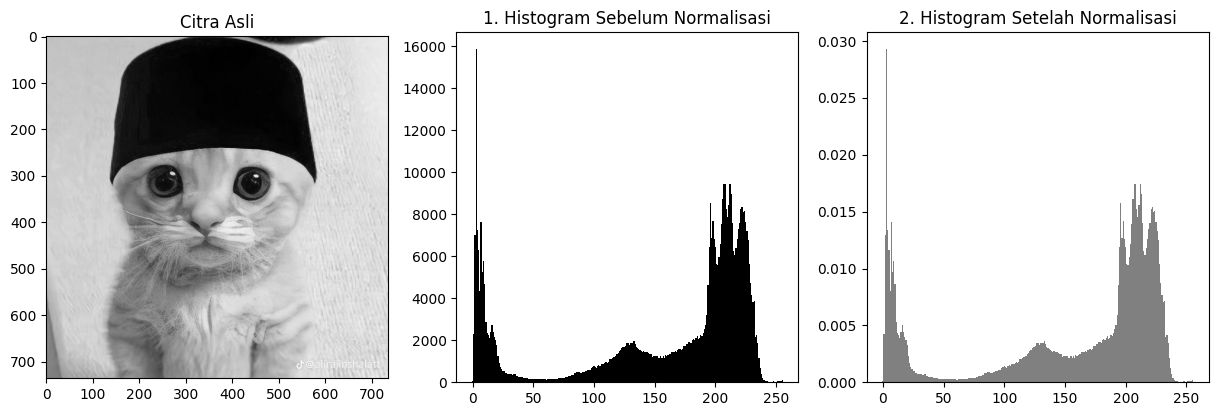

In [23]:
# --- Visualisasi ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1); plt.imshow(img, cmap='gray'); plt.title("Citra Asli")

plt.subplot(2, 3, 2)
plt.bar(range(256), hist_raw, color='black', width=1.0)
plt.title("1. Histogram Sebelum Normalisasi")

plt.subplot(2, 3, 3)
plt.bar(range(256), hist_norm, color='gray', width=1.0)
plt.title("2. Histogram Setelah Normalisasi")

In [24]:
# Fungsi Histogram Equalization
def histogram_equalization(image, hist_norm):
    cdf = np.zeros(256, dtype=float)
    cumulative_sum = 0
    for i in range(256):
        cumulative_sum += hist_norm[i]
        cdf[i] = cumulative_sum

    transform_map = np.floor(cdf * 255).astype(np.uint8)

    img_new = np.zeros_like(image)
    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            img_new[i, j] = transform_map[image[i, j]]
    return img_new

img_equalized = histogram_equalization(img, hist_norm)
hist_equalized_raw = get_histogram_raw(img_equalized)
hist_equalized_norm = get_histogram_normalized(hist_equalized_raw, N, M)

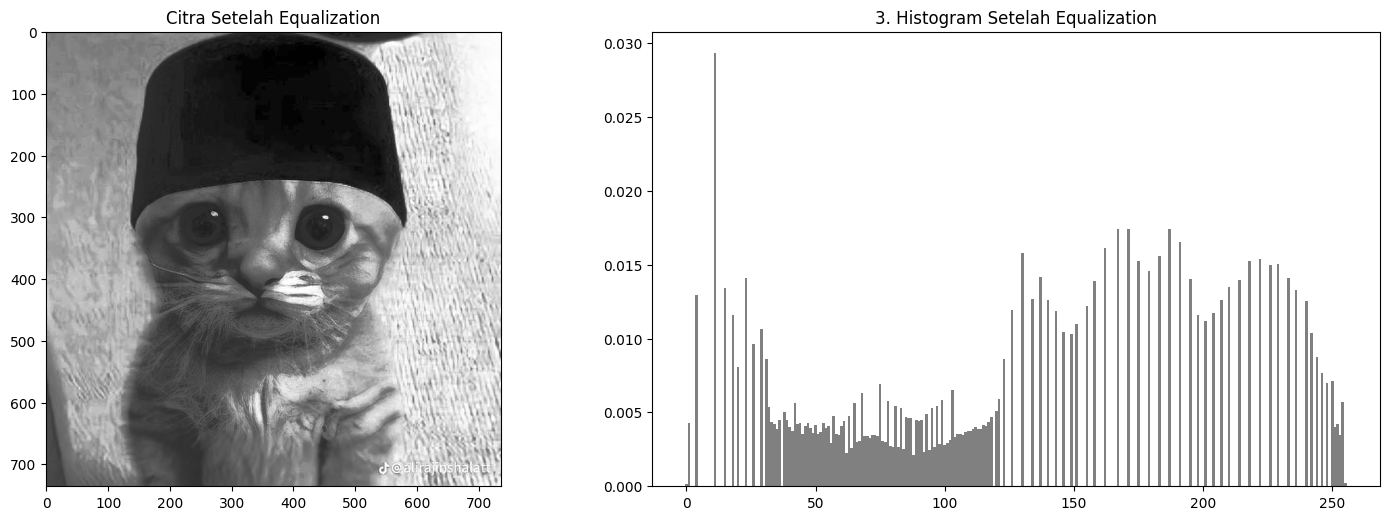

In [26]:
# --- Visualisasi ---
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1); plt.imshow(img_equalized, cmap='gray'); plt.title("Citra Setelah Equalization")

# 3. Setelah Equalization
plt.subplot(2, 2, 2)
plt.bar(range(256), hist_equalized_norm, color='gray', width=1.0)
plt.title("3. Histogram Setelah Equalization")

plt.tight_layout()
plt.show()